# Week3 (Regression) 과제
## Boston Housing Data 분석
### 데이터 소개
- **CRIM**: Per capita crime rate by town.
- **ZN**: Proportion of residential land zoned for lots over 25,000 square feet.
- **INDUS**: Proportion of non-retail business acres per town.
- **CHAS**: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).
- **NOX**: Nitric oxide concentration (parts per 10 million).
- **RM**: Average number of rooms per dwelling.
- **AGE**: Proportion of owner-occupied units built prior to 1940.
- **DIS**: Weighted distances to five Boston employment centers.
- **RAD**: Index of accessibility to radial highways.
- **TAX**: Full-value property tax rate per $10,000.
- **PTRATIO**: Pupil-teacher ratio by town.
- **B**: 1000(Bk - 0.63)^2 where Bk is the proportion of Black residents by town.
- **LSTAT**: Percentage of lower status of the population.

Target Variable:
- **MEDV**: Median value of owner-occupied homes in $1000s.

In [1]:
# 코랩 환경: 구글 드라이브를 코랩에 연동 (로컬에서 해서 따로 설정했습니다.)
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ModuleNotFoundError:
    print("로컬 환경 - 드라이브 마운트 생략")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# housing.xls가 포함된 경로를 저장해봅시다.
PATH = ''

In [ ]:
# 본인 구글 드라이브에 업로드한 housing.xls 파일의 주소를 넣어주세요!
house = pd.read_excel(PATH+'housing.xls')

# Q1: `head`, `info`, `describe`, `shape` 함수를 실행해봅시다.

과제2 참고

In [ ]:
# .head()
display(house.head())

# .info()
house.info()

# .describe()
display(house.describe())

# .shape
print("shape:", house.shape)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


shape: (506, 14)


# Q2: 각 변수의 결측치 (NaN 또는 Null)의 개수를 구해봅시다.

과제2 참고

In [6]:
# NaN의 개수 구하기
house.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

**모든 변수에서 결측치(NaN)는 0개입니다.** 다만 NaN이 아니어도 실제로는 신뢰하기 어려운 값(예: 상한 검열된 것으로 보이는 MEDV=50)이 있는지 추가로 확인했습니다.

# Q3: 각 변수별로 히스토그램을 그리고, Scatterplot Matrix를 그려봅시다

과제2 참고

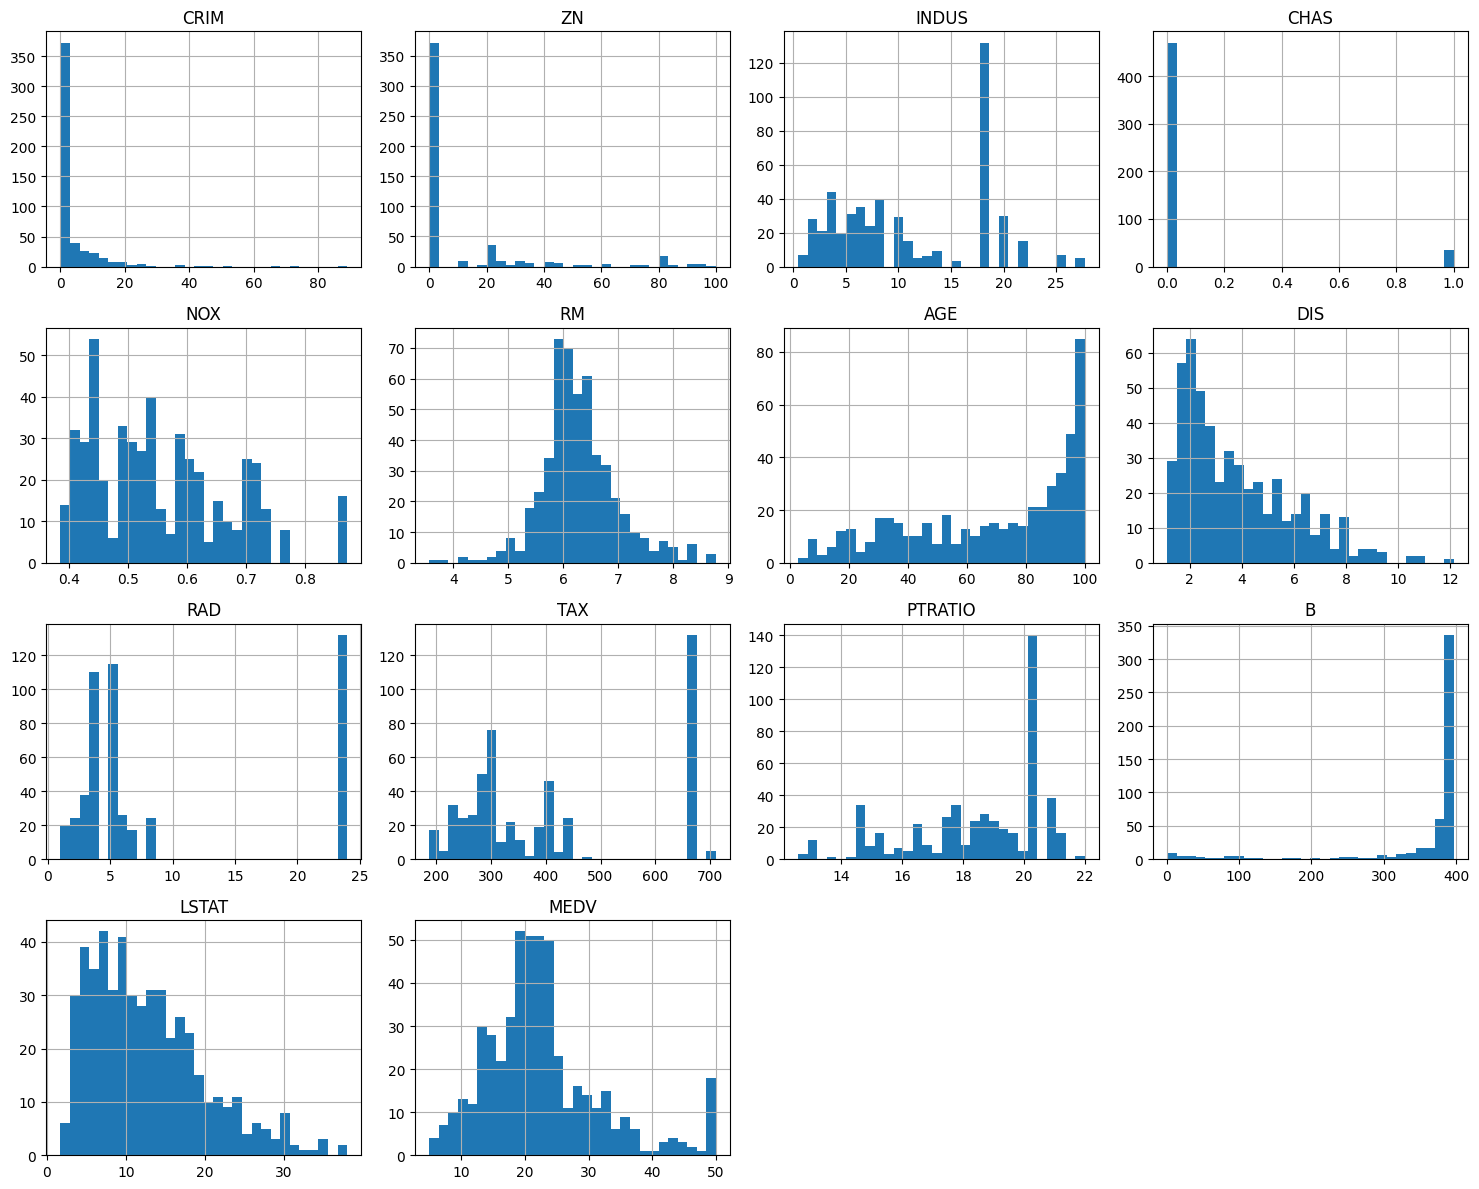

In [ ]:
# Histogram
house.hist(bins=30, figsize=(15, 12))
plt.tight_layout()
plt.show()

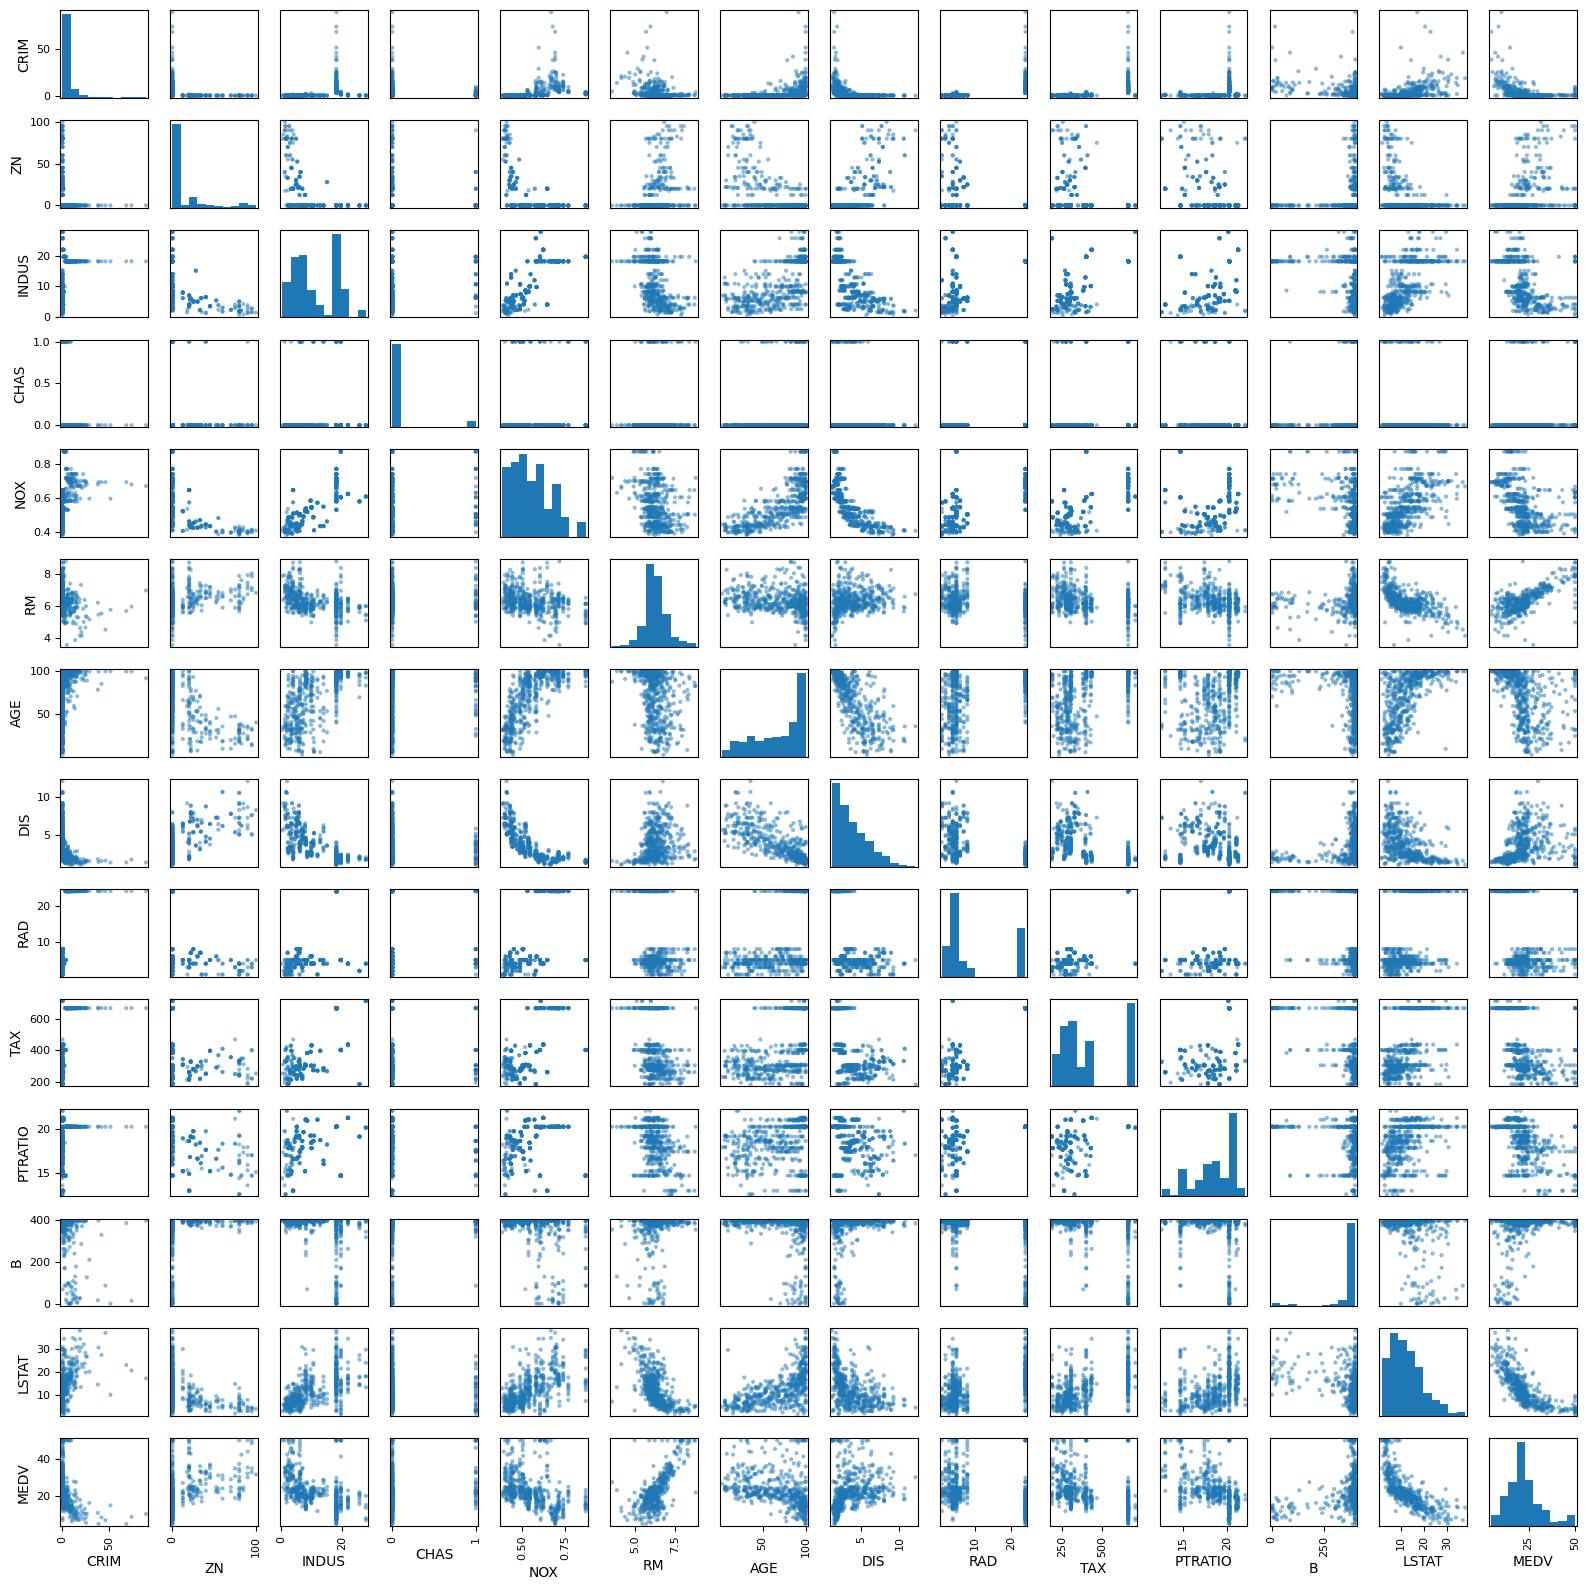

In [ ]:
# Scatterplot Matrix
pd.plotting.scatter_matrix(house, figsize=(16, 16), diagonal='hist')
plt.tight_layout()
plt.show()

### Q3. 히스토그램·산점도행렬에서 관찰한 점

결측치(NaN)는 0개였지만, 분포를 직접 그려보니 값이 채워져 있어도 그대로 믿기 어려운 부분이 있는지 확인을 꼼꼼히 해봤습니다.

** MEDV(타깃)가 50에서 잘려 있습니다.**
히스토그램에서 맨 오른쪽 50 자리에 막대가 튀어 있어 직접 세어보았습니다.

| MEDV | 개수 |
|---|---|
| 50.0 | 16 |
| 48.8 / 48.5 / 48.3 … | 각 1개 |

50 아래 값들은 전부 1개씩인데, 최댓값이자 딱 떨어지는 50에만 16개가 몰려 있습니다. 50을 넘는 경우를 내림 처리했다고 봤습니다.

외에는 제가 판단하기에는 없습니다!

## Q3-1. 다중공선성(multicolinearity)을 확인하기 위해 VIF를 추가로 확인해봅시다.

In [ ]:
# 그대로 실행하기 !!
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['VIF Factor'] = [variance_inflation_factor(house.values, i) for i in range(house.shape[1])]
vif['features'] = house.columns
vif 

,VIF Factor,features
0,2.131404,CRIM
1,2.910004,ZN
2,14.485874,INDUS
3,1.176266,CHAS
4,74.004269,NOX
5,136.101743,RM
6,21.398863,AGE
7,15.430455,DIS
8,15.369980,RAD
9,61.939713,TAX


## Q3-2. 
VIF가 높은 변수가 하나씩 줄어들면 다른 변수들의 VIF에도 영향을 미치기 때문에 변수들을 한 번에 다 제거하기보다는 하나씩 제거하면서 확인해 나아가는 것이 바람직합니다! 여러 차례 VIF를 확인해보면서 변수를 제거해보세요!

In [ ]:
vif = pd.DataFrame()
x_data = house.drop('TAX', axis=1) # VIF 높은 변수 기입 (아래 셀에서 다시 계산해 고른 TAX)
vif["VIF Factor"] = [variance_inflation_factor(x_data.values, i) for i in range(x_data.shape[1])]
vif["features"] = x_data.columns
vif

,VIF Factor,features
0,2.130735,CRIM
1,2.743161,ZN
2,11.778793,INDUS
3,1.164024,CHAS
4,72.200885,NOX
5,135.363146,RM
6,21.391732,AGE
7,15.408578,DIS
8,5.612793,RAD
9,85.075361,PTRATIO


In [46]:

# 위 결과가 전반적으로 너무 커서 상수항을 넣어서 보는 것이 맞다고 판단해 다시 한번 코드 짜봤습니다.
from statsmodels.tools.tools import add_constant

def calc_vif(df):
    dfc = add_constant(df)
    out = pd.DataFrame({
        'features': dfc.columns,
        'VIF Factor': [variance_inflation_factor(dfc.values, i) for i in range(dfc.shape[1])]
    })
    return out[out['features'] != 'const'].sort_values('VIF Factor', ascending=False).reset_index(drop=True)

X = house.drop('MEDV', axis=1)   # 설명변수만 (타깃 제외)

print('== 다시 계산한 VIF (타깃 제외 + 상수항 포함) ==')
display(calc_vif(X))

print('== TAX 제거 후 ==')
display(calc_vif(X.drop('TAX', axis=1)))

== 다시 계산한 VIF (타깃 제외 + 상수항 포함) ==


,features,VIF Factor
0,TAX,9.008554
1,RAD,7.484496
2,NOX,4.393720
3,INDUS,3.991596
4,DIS,3.955945
5,AGE,3.100826
6,LSTAT,2.941491
7,ZN,2.298758
8,RM,1.933744
9,PTRATIO,1.799084


== TAX 제거 후 ==


,features,VIF Factor
0,NOX,4.369271
1,DIS,3.954446
2,INDUS,3.226015
3,AGE,3.098044
4,LSTAT,2.940800
5,RAD,2.837494
6,ZN,2.184240
7,RM,1.923075
8,CRIM,1.791940
9,PTRATIO,1.788839


### Q3-2. VIF를 다시 계산한 이유

위 "그대로 실행하기" 셀의 VIF를 그대로 쓰려다가, 값이 좀 이상해서(RM 136, PTRATIO 87) 왜 이렇게 큰지 따져봤습니다. 두 가지가 걸렸습니다.

- 계산에 타깃 MEDV가 함께 들어가 있습니다. VIF는 설명변수끼리 얼마나 겹치는지를 보는 값이라, 타깃은 빼는 게 맞다고 봤습니다.
- 상수항(절편)이 없습니다. VIF 안의 R²는 "그 변수의 변동이 다른 변수들로 설명되는 비율"인데, 절편이 없으면 변동이 아니라 값의 수준(레벨)을 재게 되는 것 같습니다. 그래서 평균이 0에서 먼 변수(NOX, PTRATIO, RM)가 실제 겹침과 무관하게 커진다고 이해했습니다.

두 번째가 맞는지 확신이 안 서서, 데이터를 표준화(평균 0)한 뒤 절편 없이 다시 재봤습니다. 그랬더니 절편을 넣은 값과 소수점까지 같아서, 차이가 전적으로 절편 때문이라고 판단했습니다. 그래서 절편을 넣고 타깃을 뺀 값을 쓰기로 했습니다.

| 변수 | 그대로 실행 | 다시 계산 |
|---|---|---|
| RM | 136.1 | 1.9 |
| PTRATIO | 87.2 | 1.8 |
| NOX | 74.0 | 4.4 |
| TAX | 61.9 | 9.0 |
| RAD | 15.4 | 7.5 |

제거 기준은 VIF 5로 잡았습니다(알려진 기준). 그 위로 올라온 건 TAX(9.0)와 RAD(7.5) 둘뿐이었는데(10을 넘는 건 없었습니다), 이 둘은 앞 산점도행렬에서 RAD=24와 TAX=666이 같은 132개 행에 겹쳐 있던 그 쌍이라 서로 얽혀 있다고 봤습니다. 서로끼리 겹친 쌍은 하나만 빼면 나머지도 풀리기 때문에, 둘 중 VIF가 더 큰 TAX를 빼고 다시 재봤습니다. 그러자 RAD도 7.5 → 2.8로 내려가고 남은 변수가 전부 5 아래여서, 더 뺄 것이 없다고 보고 멈췄습니다.

다만 기준을 10으로 더 엄격히 잡으면 TAX(9.0)조차 걸리지 않아 아무것도 안 빼도 됩니다. 그래서 여기서 뺀 한 개가 성능에 실제로 의미가 있는지는 Q6-1에서 MSE로 확인해보려 합니다. 

**house 데이터셋에 변수 제거를 적용하지 않고 우선 진행하세요! 추후에 MSE 비교를 통해 변수 제거를 확실히 해봅시다.**

# Q4: 데이터를 `X_train`, `X_test`, `y_train`, `y_test` 로 split해 봅시다

split 비율은 자유롭게 정해보시기 바랍니다.

In [47]:
# train_test_split
X = house.drop('MEDV', axis=1)   # 설명변수 13개 (변수 제거는 지시대로 Q6-1에서)
y = house['MEDV']                # 타깃

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('y_train:', y_train.shape, '| y_test:', y_test.shape)

X_train: (404, 13) | X_test: (102, 13)
y_train: (404,) | y_test: (102,)


# Q5: `StandardScaler`로 표준화를 해봅시다

CRIM, ZN, INDUS, NOX, RM, AGE, DIS, TAX, PTRATIO, B, LSTAT 변수들만 `StandardScaler`을 해봅시다. (이들 중 다중공선성으로 인해 제거한 변수들이 있다면 제외하고 진행해주세요.)

`X_train`은 `fit_transform`, `X_test`는 `transform`을 이용하는 것에 유의합시다!

In [ ]:
# StandardScaler
scale_cols = ['CRIM','ZN','INDUS','NOX','RM','AGE','DIS','TAX','PTRATIO','B','LSTAT']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

# X_train은 fit_transform(기준을 학습), X_test는 transform(그 기준으로 변환만)
X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols]  = scaler.transform(X_test[scale_cols])

display(X_train_scaled.head())

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
477,1.287702,-0.500320,1.033237,0,0.489252,-1.428069,1.028015,-0.802173,24,1.578434,0.845343,-0.074337,1.753505
15,-0.336384,-0.500320,-0.413160,0,-0.157233,-0.680087,-0.431199,0.324349,4,-0.584648,1.204741,0.430184,-0.561474
332,-0.403253,1.013271,-0.715218,0,-1.008723,-0.402063,-1.618599,1.330697,1,-0.602724,-0.637176,0.065297,-0.651595
423,0.388230,-0.500320,1.033237,0,0.489252,-0.300450,0.591681,-0.839240,24,1.578434,0.845343,-3.868193,1.525387
19,-0.325282,-0.500320,-0.413160,0,-0.157233,-0.831094,0.033747,-0.005494,4,-0.584648,1.204741,0.379119,-0.165787


# Q6: 5-fold Cross-Validation으로 `LinearRegression`을 적합해봅시다.

각 fold마다 적합 후 MSE, MAE, RMSE, $R^2$를 구하고, coefficient과 intercept를 `print` 해보세요.

In [ ]:
# KFold, cross_val_score, cross_validation 이용
from sklearn.model_selection import KFold

def run_cv(X, y, seed=42, verbose=True):
    base_scale = ['CRIM','ZN','INDUS','NOX','RM','AGE','DIS','TAX','PTRATIO','B','LSTAT']
    scale_cols = [c for c in base_scale if c in X.columns]
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    rows, last_model = [], None
    for fold, (tr, va) in enumerate(kf.split(X), 1):
        X_tr, X_va = X.iloc[tr].copy(), X.iloc[va].copy()
        y_tr, y_va = y.iloc[tr], y.iloc[va]
        sc = StandardScaler()
        X_tr[scale_cols] = sc.fit_transform(X_tr[scale_cols])
        X_va[scale_cols] = sc.transform(X_va[scale_cols])
        model = LinearRegression().fit(X_tr, y_tr)
        pred = model.predict(X_va)
        mse  = metrics.mean_squared_error(y_va, pred)
        mae  = metrics.mean_absolute_error(y_va, pred)
        rmse = np.sqrt(mse)
        r2   = metrics.r2_score(y_va, pred)
        rows.append([mse, mae, rmse, r2]); last_model = model
        if verbose:
            print(f'[Fold {fold}] MSE={mse:6.3f}  MAE={mae:5.3f}  RMSE={rmse:5.3f}  R2={r2:.3f}  | intercept={model.intercept_:6.2f}')
    res = pd.DataFrame(rows, columns=['MSE','MAE','RMSE','R2'])
    if verbose:
        print('--- 5-fold 평균 ---')
        print(res.mean().round(3).to_string())
    return res, last_model

# Q6: 전체 13개 변수 (기준선)
res_full, model_full = run_cv(X, y)

print('\n--- 마지막 fold 계수 (표준화된 값 기준이라 크기 비교 가능) ---')
print(pd.Series(model_full.coef_, index=X.columns).round(2).to_string())

### Q6-1: 다중공선성이 높았던 변수를 제거한 후 다시 train_test_split, scaler, 5-fold CV 과정으로 `LinearRegression`을 적합한 후 Q6에서 구한 평균 MSE(or MAE, RMSE, $R^2$)와 비교해보세요.

In [ ]:
# 다중공선성을 불러일으키는 변수 제거
house_new = house.drop(['TAX'], axis=1) # Q3-2에서 고른 TAX 제거 (RAD와 얽힌 쌍 중 VIF 큰 쪽)

In [ ]:
# TAX를 뺀 버전으로 Q6와 동일한 5-fold CV (run_cv 재사용 → scaler·CV 절차 동일)
X_notax = house_new.drop('MEDV', axis=1)   # house_new: TAX 제거됨, 여기서 타깃도 분리
y = house_new['MEDV']

print('=== TAX 제거 버전 (12개 변수) ===')
res_notax, model_notax = run_cv(X_notax, y)

# Q6(전체) vs Q6-1(TAX 제거) 평균 비교
compare = pd.DataFrame({
    '전체(13개)':   res_full.mean(),
    'TAX제거(12개)': res_notax.mean(),
    '차이':         res_notax.mean() - res_full.mean()
}).round(4)
print('\n=== 평균 비교 ===')
print(compare.to_string())

### Q6-1. TAX 제거 전후 비교

Q6와 똑같은 5-fold CV 절차를 TAX만 뺀 12개 변수로 다시 돌려 평균을 비교했습니다.

| 지표 | 전체(13개) | TAX 제거(12개) | 차이 |
|---|---|---|---|
| MSE | 23.49 | 24.09 | +0.60 |
| MAE | 3.39 | 3.44 | +0.06 |
| RMSE | 4.84 | 4.90 | +0.06 |
| R² | 0.715 | 0.708 | −0.007 |

TAX를 빼도 성능은 사실상 그대로였고, 오히려 아주 조금(MSE +0.6, 전체의 약 2.5%) 나빠졌습니다만, 노이즈 범위라고 봤습니다.

정리하면, VIF가 높다고 그 변수를 빼는 것이 예측 성능에는 도움이 되지 않았습니다. TAX와 RAD가 서로 겹쳐도 선형회귀는 둘을 적당히 나눠 쓰기 때문에 예측 자체는 멀쩡했던 것 같습니다. 다중공선성이 실제로 문제되는 곳은 예측이 아니라 개별 계수의 해석(어느 변수가 얼마나 기여하는지)이라고 이해했습니다.

그래서 예측이 목적이라면 TAX를 굳이 빼지 않아도 되고, 계수 해석이 목적이라면 빼서 RAD·TAX의 얽힘을 푸는 편이 낫다고 봤습니다.

# Q7(Optional): `GridSearchCV`를 이용하여 `Lasso`를 적합해봅시다.

찾아야 하는 최적 파라미터는

- `alpha`: 0.01, 0.1, 1, 10 중에서 찾기
- `fit_intercept`: `True`, `False`에서 찾기

https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter

위 링크를 참조하여 `GridSearCV`의 `scoring`을 3가지 이상 사용해보세요

In [51]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso',  Lasso(max_iter=10000))
])

# param_grid
param_grid = {
    'lasso__alpha':         [0.01, 0.1, 1, 10],
    'lasso__fit_intercept': [True, False],
}

# scoring 3가지 (MSE / MAE / R2).
scoring = ['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']

grid = GridSearchCV(
    pipe, param_grid,
    scoring=scoring,
    refit='neg_mean_squared_error',            # MSE 기준으로 최적 모델 선택
    cv=KFold(5, shuffle=True, random_state=42)
)
grid.fit(X, y)

print('최적 파라미터:', grid.best_params_)

# 결과 정리 (부호 뒤집어 MSE·MAE를 양수로)
res = pd.DataFrame(grid.cv_results_)
show = res[['param_lasso__alpha', 'param_lasso__fit_intercept',
            'mean_test_neg_mean_squared_error',
            'mean_test_neg_mean_absolute_error',
            'mean_test_r2']].copy()
show['mean_test_neg_mean_squared_error'] *= -1
show['mean_test_neg_mean_absolute_error'] *= -1
show.columns = ['alpha', 'fit_intercept', 'MSE', 'MAE', 'R2']
display(show.sort_values('MSE').reset_index(drop=True))

최적 파라미터: {'lasso__alpha': 0.01, 'lasso__fit_intercept': True}


,alpha,fit_intercept,MSE,MAE,R2
0,0.01,True,23.478501,3.379101,0.715342
1,0.10,True,24.001317,3.367337,0.708989
2,1.00,True,29.295220,3.747860,0.647528
3,10.00,True,84.778153,6.665410,-0.011228
4,0.01,False,531.410876,22.536415,-5.468638
5,0.10,False,531.686925,22.531111,-5.469423
6,1.00,False,536.498960,22.521467,-5.517022
7,10.00,False,592.259925,22.534875,-6.142787


### Q7. Lasso GridSearchCV 결과

Lasso는 스케일에 민감해서, 스케일링을 fold 안에서 적용하려고 Pipeline으로 묶어 돌렸습니다(누수 방지). scoring은 MSE·MAE·R² 세 가지를 주고, 최종 선택은 MSE 기준으로 했습니다.

| alpha | fit_intercept | MSE | MAE | R² |
|---|---|---|---|---|
| 0.01 | True | 23.48 | 3.38 | 0.715 |
| 0.10 | True | 24.00 | 3.37 | 0.709 |
| 1.00 | True | 29.30 | 3.75 | 0.648 |
| 10.0 | True | 84.78 | 6.67 | −0.011 |
| 0.01~10 | False | 531~592 | ~22.5 | −5.5~−6.1 |

두 가지가 보였습니다.

- **최적은 alpha=0.01(가장 작은 값), fit_intercept=True**였고, 그때 MSE 23.48로 **일반 LinearRegression(23.49)과 사실상 같았습니다.** alpha를 키울수록(0.1 → 1 → 10) 계속 나빠져서, 이 데이터에는 규제가 도움이 안 된다고 봤습니다. 계수를 억지로 줄여야 할 만큼의 과적합이 없다는 뜻으로 이해했습니다.
- 혹시나 해본 fit_intercept=False는 성능이 크게 하락(R² −5.5)했습니다.

정리하면 Lasso로도 성능은 오르지 않았고, 규제가 필요 없을 만큼 단순한 선형 구조라는 관찰이 한 번 더 확인됐습니다.

# Q8(Optional): `RandomizedSearchCV`를 이용하여 `Ridge`를 적합해 봅시다.

CV를 이용한 hyperparameter tuning의 또다른 방법은 `RandomizedSearchCV`입니다.
Tuning해야 하는 모수가 많을 경우 이 방법이 빠르다는 장점이 있습니다.

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html#

위 링크를 참조하거나 구글링을 하여 `Ridge`를 적합해보세요.

`n_iter`와, 파라미터 공간을 자유롭게 조정해보세요.

In [52]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import Ridge
from scipy.stats import loguniform


pipe_r = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge',  Ridge())
])

param_dist = {
    'ridge__alpha':         loguniform(1e-3, 1e2),   # 0.001~100 로그스케일에서 무작위 추출
    'ridge__fit_intercept': [True, False],
}

rand = RandomizedSearchCV(
    pipe_r, param_dist,
    n_iter=20,
    scoring=['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'],
    refit='neg_mean_squared_error',
    cv=KFold(5, shuffle=True, random_state=42),
    random_state=42
)
rand.fit(X, y)

print('최적 파라미터:', rand.best_params_)

res_r = pd.DataFrame(rand.cv_results_)
show_r = res_r[['param_ridge__alpha', 'param_ridge__fit_intercept',
                'mean_test_neg_mean_squared_error',
                'mean_test_neg_mean_absolute_error',
                'mean_test_r2']].copy()
show_r['param_ridge__alpha'] = show_r['param_ridge__alpha'].astype(float).round(3)
show_r['mean_test_neg_mean_squared_error'] *= -1
show_r['mean_test_neg_mean_absolute_error'] *= -1
show_r.columns = ['alpha', 'fit_intercept', 'MSE', 'MAE', 'R2']
display(show_r.sort_values('MSE').reset_index(drop=True))

최적 파라미터: {'ridge__alpha': 0.9846738873614566, 'ridge__fit_intercept': True}


,alpha,fit_intercept,MSE,MAE,R2
0,0.985,True,23.487528,3.383304,0.715241
1,1.144,True,23.487595,3.382526,0.715241
2,0.421,True,23.487812,3.386139,0.715234
3,0.216,True,23.488130,3.387265,0.715229
4,0.191,True,23.488177,3.387403,0.715228
5,0.169,True,23.488218,3.387520,0.715227
6,0.144,True,23.488269,3.387659,0.715227
7,0.075,True,23.488419,3.388046,0.715224
8,73.923,True,24.721167,3.369585,0.701088
9,14.528,False,531.371681,22.532639,-5.466754


### Q8. Ridge RandomizedSearchCV 결과

Ridge도 규제 모델이라 Pipeline으로 스케일을 묶고, 이번엔 격자 대신 RandomizedSearchCV로 alpha를 로그스케일(0.001~100)에서 20번 무작위 추출해 탐색했습니다. scoring은 Q7과 같이 세 가지입니다.

- **최적은 alpha≈0.98, fit_intercept=True → MSE 23.49, R² 0.715로 역시 LinearRegression과 동일**했습니다. fit_intercept=True인 조합은 alpha가 어떤 값이든 성능이 거의 안 변했는데(모두 R²≈0.715), Ridge는 계수를 부드럽게 줄일 뿐 0으로 없애지는 않아 웬만한 alpha에 둔감하기 때문이라고 봤습니다.
- fit_intercept=False는 Q7의 Lasso와 똑같이 붕괴(R²≈−5.5)했습니다.

Q7 Lasso와 비교하면 작은 차이가 하나 있었습니다. Lasso는 최적 alpha가 가장 작은 값(0.01)이었는데 Ridge는 alpha≈1을 골랐습니다. Lasso(L1)는 alpha가 조금만 커져도 계수를 아예 0으로 만들어 쓸모 있는 변수까지 버리기 때문에 alpha를 최소로 원하고, Ridge(L2)는 계수를 부드럽게 줄이기만 해서 어느 정도의 alpha는 손해가 거의 없다고 이해했습니다.

다만 두 경우 모두 최종 성능은 LinearRegression과 사실상 같았습니다. 이 데이터에서는 규제 방식이나 탐색 방법과 무관하게 단순 선형회귀가 이미 최선이라는 결론이 반복됐습니다.